# 🗺️ 20 - Contour Plots & Heatmaps

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 🎯 Learning Objectives

- Creating basic contour plots
- Filled contour plots (contourf)
- Customizing contour levels and colors
- Adding labels to contour lines
- Combining contours with other plots
- Creating heatmaps with imshow

## 📐 1. Basic Contour Plot

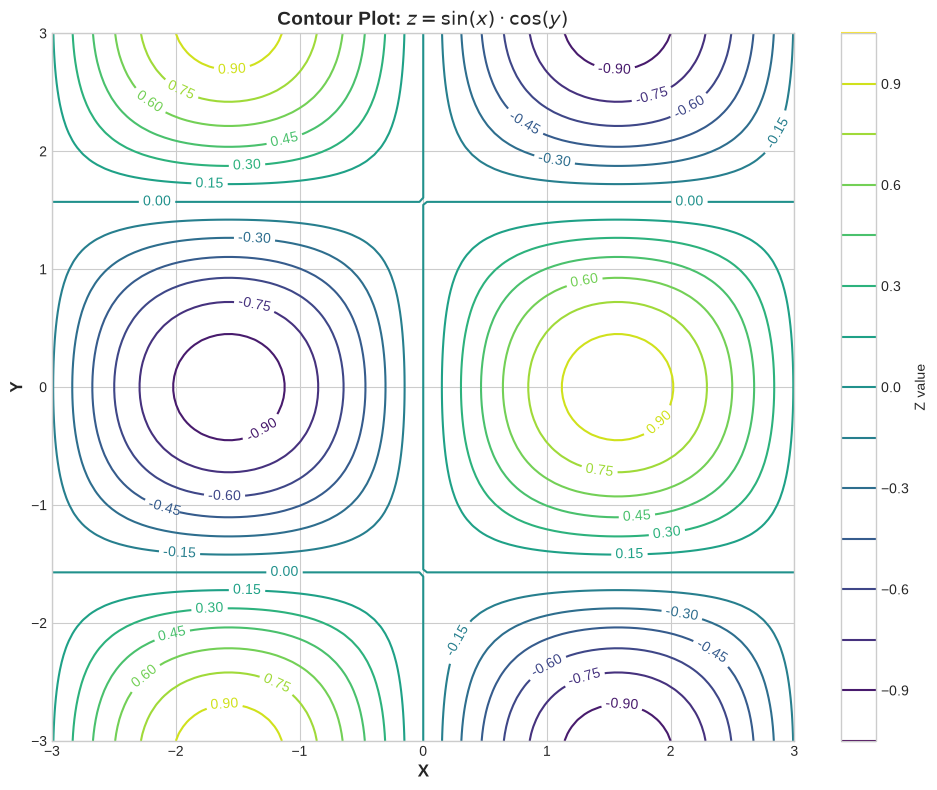

In [2]:
# Create a meshgrid
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

fig, ax = plt.subplots(figsize=(10, 8))

# Create contour plot
contour = ax.contour(X, Y, Z, levels=15, cmap='viridis', linewidths=1.5)

# Add contour labels
ax.clabel(contour, inline=True, fontsize=10, fmt='%.2f')

ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title('Contour Plot: $z = \sin(x) \cdot \cos(y)$', fontsize=14, fontweight='bold')

plt.colorbar(contour, ax=ax, label='Z value')
plt.tight_layout()
plt.show()

## 🎨 2. Filled Contour Plot

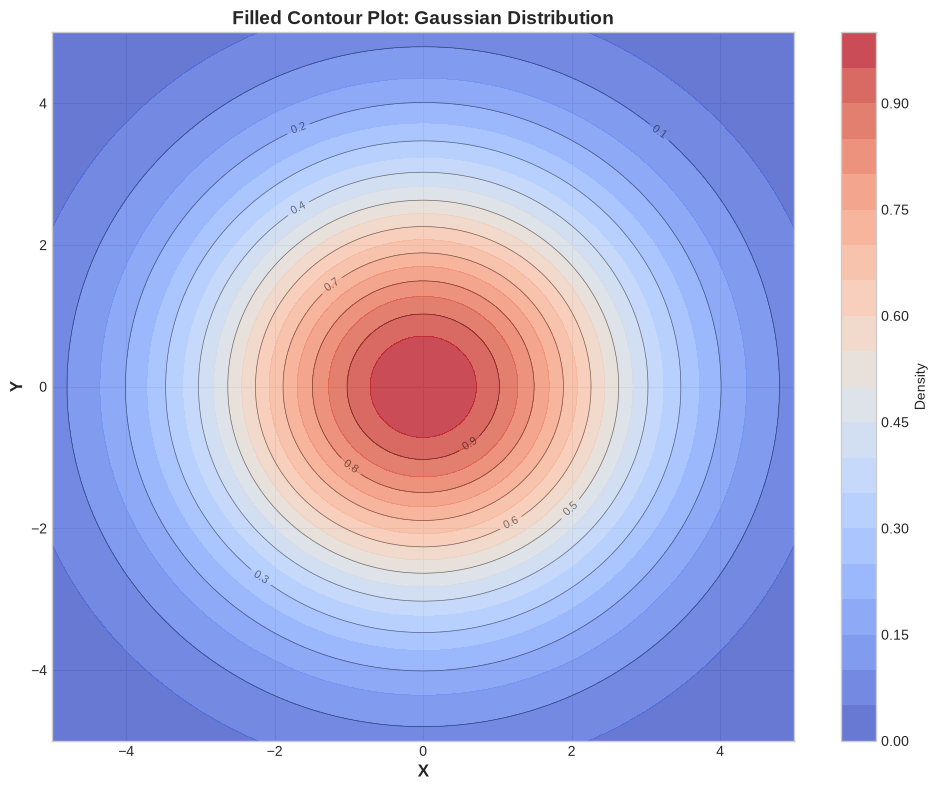

In [3]:
# Create data
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X**2 + Y**2) / 10)

fig, ax = plt.subplots(figsize=(10, 8))

# Create filled contour
contourf = ax.contourf(X, Y, Z, levels=20, cmap='coolwarm', alpha=0.8)

# Overlay contour lines
contour = ax.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5, alpha=0.5)
ax.clabel(contour, inline=True, fontsize=8)

ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title('Filled Contour Plot: Gaussian Distribution', fontsize=14, fontweight='bold')

plt.colorbar(contourf, ax=ax, label='Density')
plt.tight_layout()
plt.show()

## 🔥 3. Heatmap with imshow

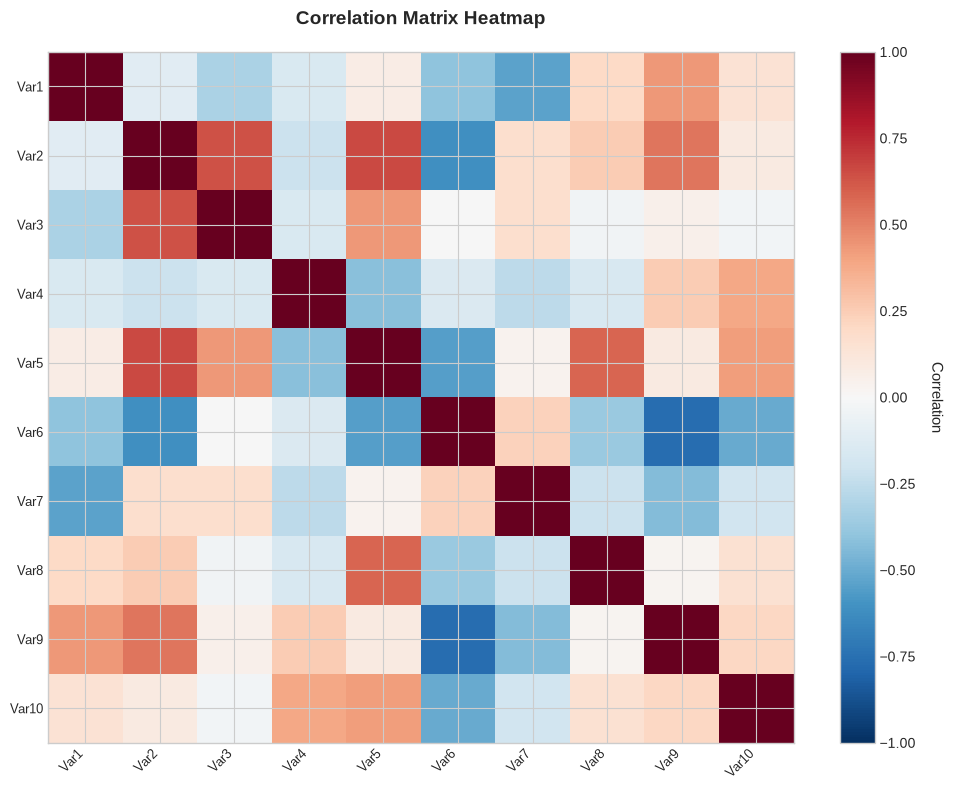

In [4]:
# Create correlation matrix-like data
np.random.seed(42)
data = np.random.randn(10, 10)
correlation_matrix = np.corrcoef(data)

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
im = ax.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', 
               interpolation='nearest', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation', rotation=270, labelpad=20, fontsize=11)

# Add grid
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xticklabels([f'Var{i+1}' for i in range(10)])
ax.set_yticklabels([f'Var{i+1}' for i in range(10)])
ax.tick_params(labelsize=9)

# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 🌡️ 4. Real-World Example: Temperature Map

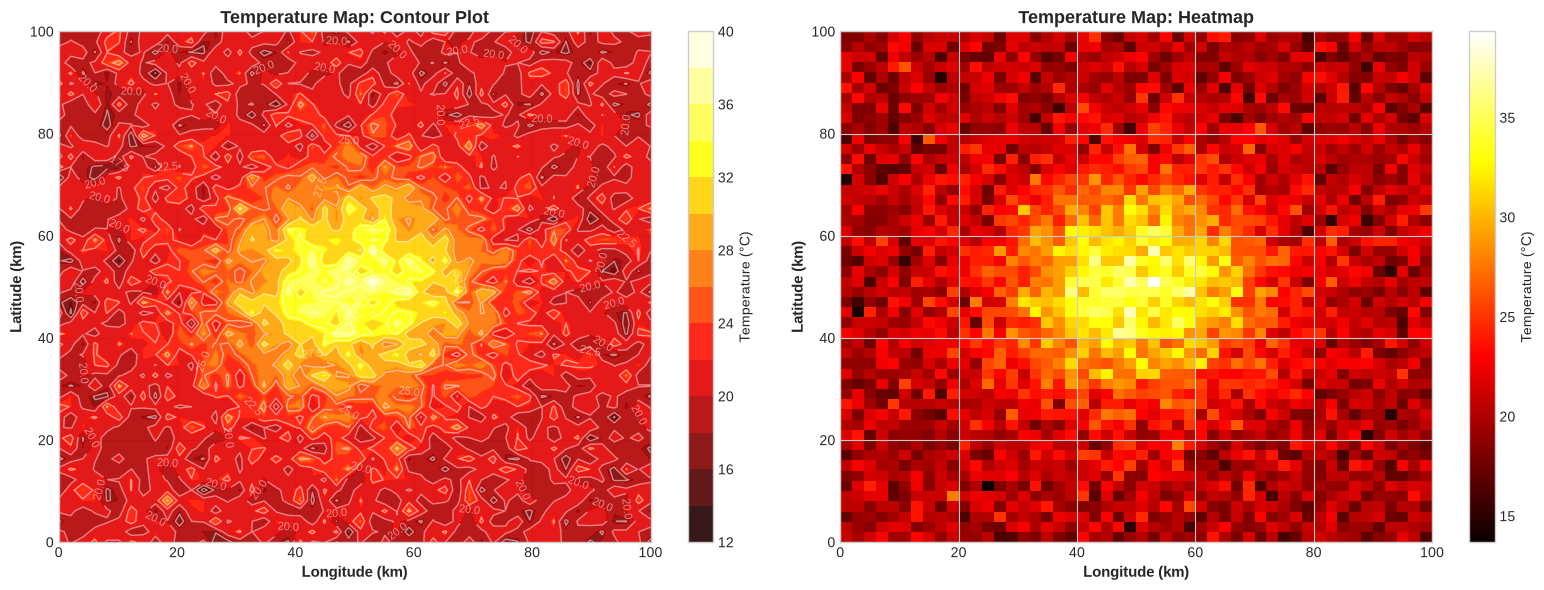

In [5]:
# Simulate temperature data across a geographic area
np.random.seed(42)
x = np.linspace(0, 100, 50)  # Longitude
y = np.linspace(0, 100, 50)  # Latitude
X, Y = np.meshgrid(x, y)

# Create temperature pattern (warmer in center, cooler at edges)
Z = 20 + 15 * np.exp(-((X-50)**2 + (Y-50)**2) / 500) + np.random.randn(50, 50) * 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Filled contour
contourf1 = ax1.contourf(X, Y, Z, levels=15, cmap='hot', alpha=0.9)
contour1 = ax1.contour(X, Y, Z, levels=10, colors='white', linewidths=1, alpha=0.5)
ax1.clabel(contour1, inline=True, fontsize=8, colors='white')
ax1.set_xlabel('Longitude (km)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Latitude (km)', fontsize=11, fontweight='bold')
ax1.set_title('Temperature Map: Contour Plot', fontsize=13, fontweight='bold')
plt.colorbar(contourf1, ax=ax1, label='Temperature (°C)')

# Right: Heatmap
im = ax2.imshow(Z, extent=[0, 100, 0, 100], origin='lower', cmap='hot', aspect='auto')
ax2.set_xlabel('Longitude (km)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Latitude (km)', fontsize=11, fontweight='bold')
ax2.set_title('Temperature Map: Heatmap', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Temperature (°C)')

plt.tight_layout()
plt.show()

## 🎨 5. Custom Contour Levels

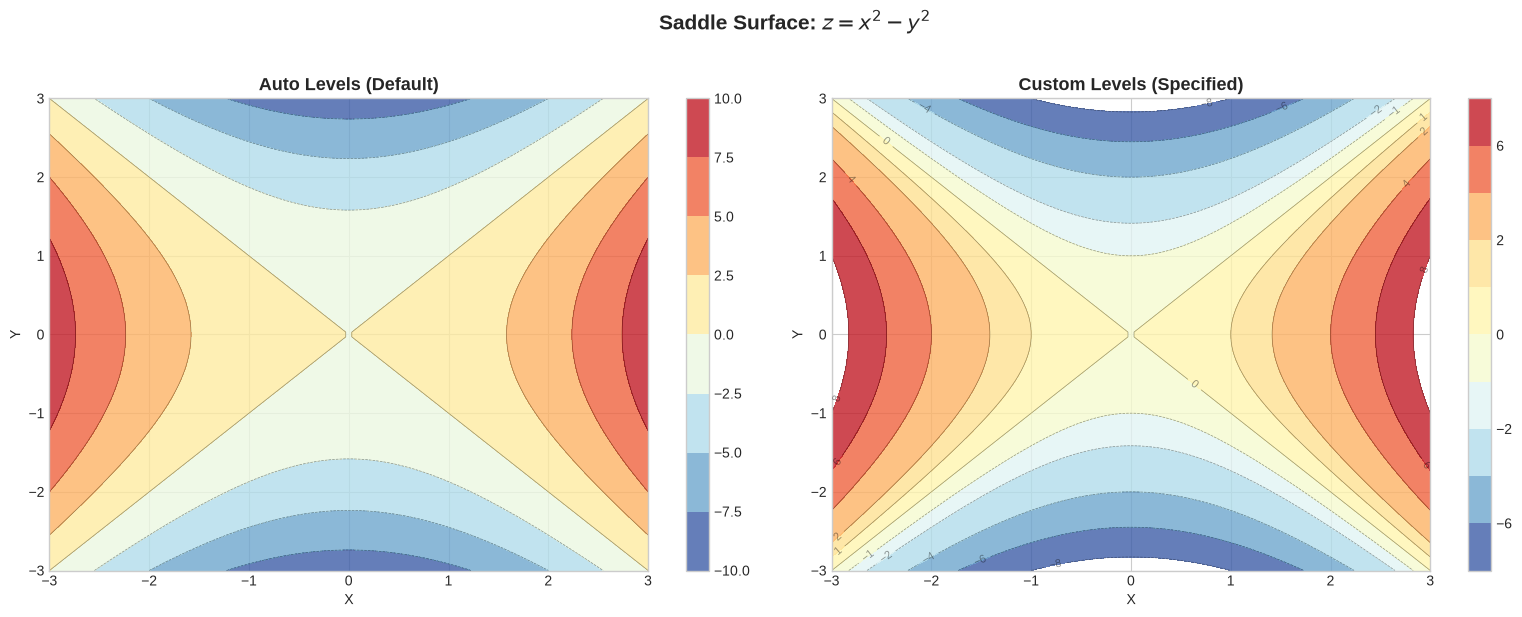

In [6]:
# Create saddle surface
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 - Y**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Auto levels
contourf1 = ax1.contourf(X, Y, Z, cmap='RdYlBu_r', alpha=0.8)
ax1.contour(X, Y, Z, colors='black', linewidths=0.5, alpha=0.4)
ax1.set_title('Auto Levels (Default)', fontsize=13, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
plt.colorbar(contourf1, ax=ax1)

# Custom levels
custom_levels = [-8, -6, -4, -2, -1, 0, 1, 2, 4, 6, 8]
contourf2 = ax2.contourf(X, Y, Z, levels=custom_levels, cmap='RdYlBu_r', alpha=0.8)
contour2 = ax2.contour(X, Y, Z, levels=custom_levels, colors='black', linewidths=0.5, alpha=0.4)
ax2.clabel(contour2, inline=True, fontsize=8)
ax2.set_title('Custom Levels (Specified)', fontsize=13, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(contourf2, ax=ax2)

plt.suptitle('Saddle Surface: $z = x^2 - y^2$', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🎯 Key Takeaways

- ✅ `contour()` creates line contours, `contourf()` creates filled contours
- ✅ Use `clabel()` to add labels to contour lines
- ✅ `imshow()` is faster for rectangular grids and heatmaps
- ✅ Specify `levels` to control contour density
- ✅ Choose appropriate colormaps (sequential, diverging, cyclic)
- ✅ Combine contour lines with filled contours for clarity
- ✅ Always add a colorbar to show the scale

## 💡 Try It Yourself

1. Create contour plots of mathematical functions
2. Visualize correlation matrices as heatmaps
3. Plot geographic or spatial data
4. Experiment with different colormaps
5. Combine contours with scatter plots for data overlay